<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Segmentation Analysis::[Dataset link](https://https://www.kaggle.com/code/analystoleksandra/marketing-analytics-customer-segmentation/input?select=ifood_df.csv)**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

**Loading and reading the dataset**

In [3]:
df= pd.read_csv("/content/ifood_df.csv")
print(df.head())
print(df.info())

    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  ...                 0   
1                2                 1             6  ...                 0   
2              111                21            42  ...                 1   
3               10                 3             5  ...                 1   
4               46                27            15  ...                 0   

   marital_Widow  education_2n Cycle  education_Basic  e

In [4]:
display(df.describe())

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


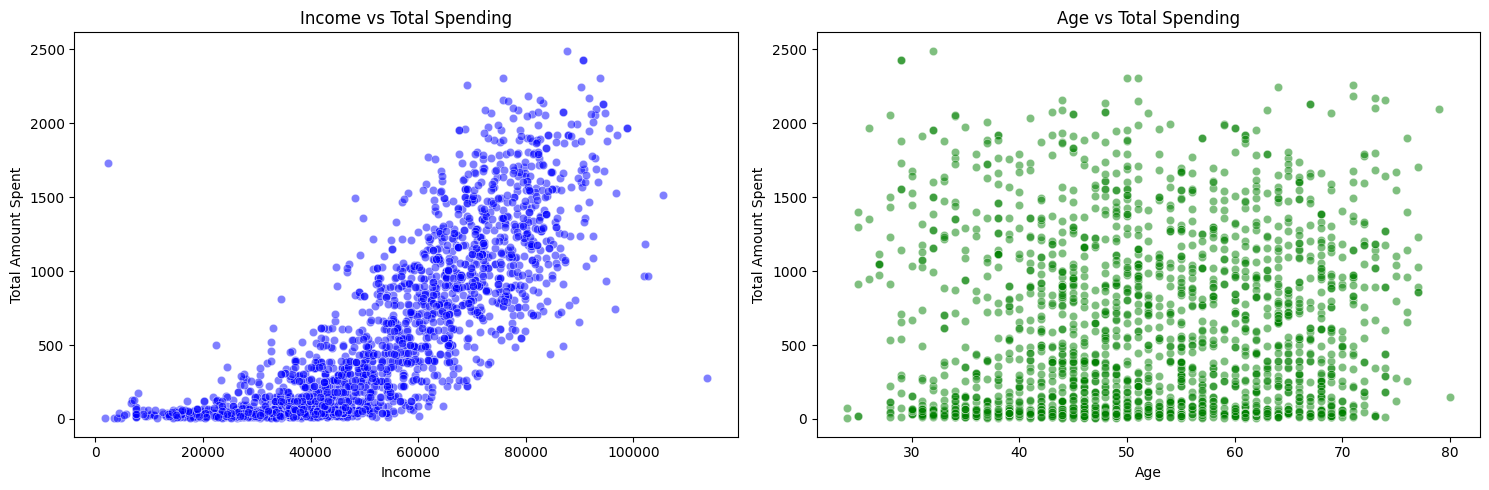

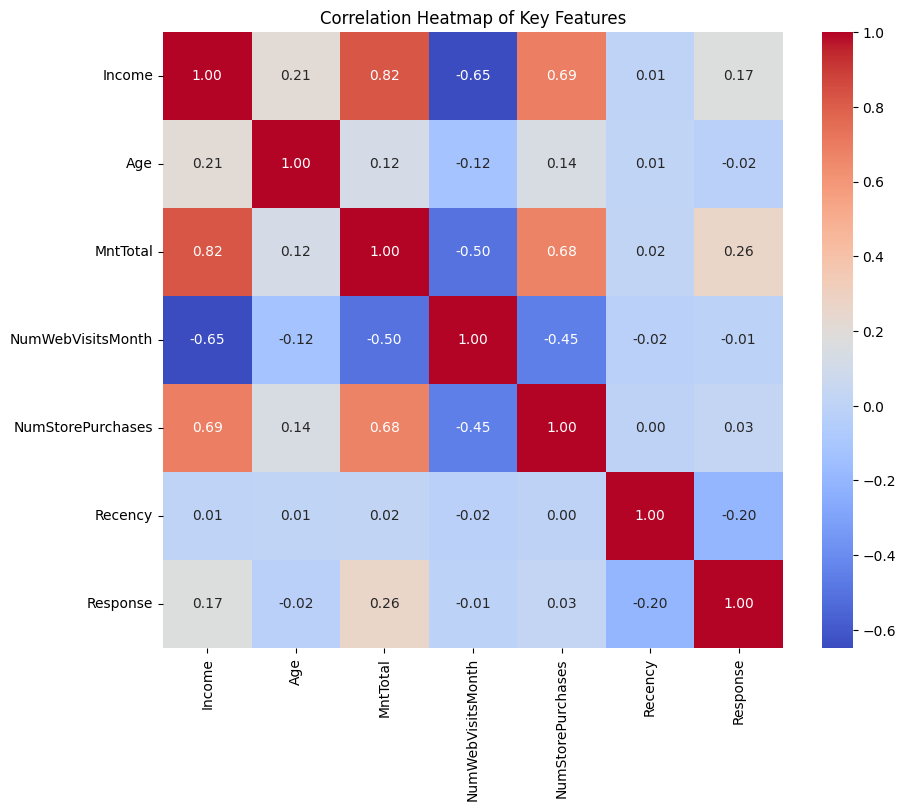

In [5]:
#Exploratory Data Analysis
plt.figure(figsize=(15, 5))

#Income vs Total Amount Spent
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Income', y='MntTotal', alpha=0.5, color='blue')
plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Amount Spent')

#Age vs Total Amount Spent
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Age', y='MntTotal', alpha=0.5, color='green')
plt.title('Age vs Total Spending')
plt.xlabel('Age')
plt.ylabel('Total Amount Spent')

plt.tight_layout()
plt.show()

# Correlation Heatmap (Selecting a subset of important numerical features to keep it readable)
cols_for_corr = ['Income', 'Age', 'MntTotal', 'NumWebVisitsMonth', 'NumStorePurchases', 'Recency', 'Response']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_for_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Features')
plt.show()

**Customer Segmentation**

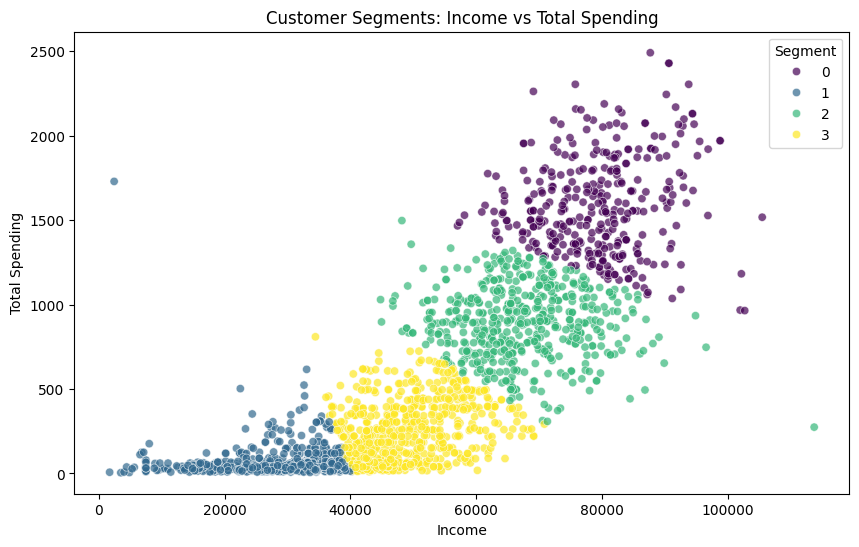

,Income,MntTotal,Age
Customer_Segment,,,
0,79245.45,1584.78,51.92
1,27611.62,64.61,46.72
2,67280.75,893.90,53.79
3,49373.05,261.00,53.17


In [6]:
#Customer Segmentation
#features for clustering
cluster_features = ['Income', 'MntTotal']
X_cluster = df[cluster_features].dropna() # Drop any potential NaNs

# Standardized the data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Apply K-Means Clustering (Let's aim for 4 distinct customer segments)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Customer_Segment'] = kmeans.fit_predict(X_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='MntTotal', hue='Customer_Segment', palette='viridis', alpha=0.7)
plt.title('Customer Segments: Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend(title='Segment')
plt.show()

# Display average metrics for each segment
segment_analysis = df.groupby('Customer_Segment')[['Income', 'MntTotal', 'Age']].mean().round(2)
display(segment_analysis)

**Predictive Modelling using random forest**

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       374
           1       0.71      0.36      0.48        67

    accuracy                           0.88       441
   macro avg       0.80      0.67      0.70       441
weighted avg       0.87      0.88      0.86       441



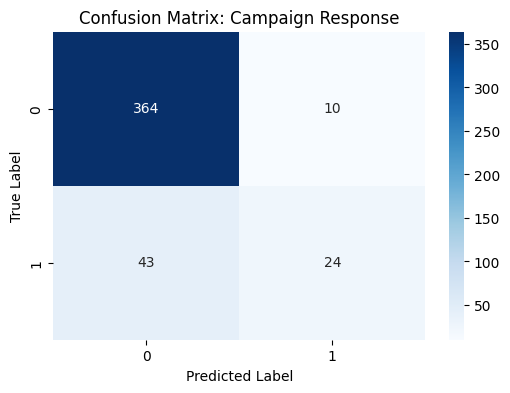

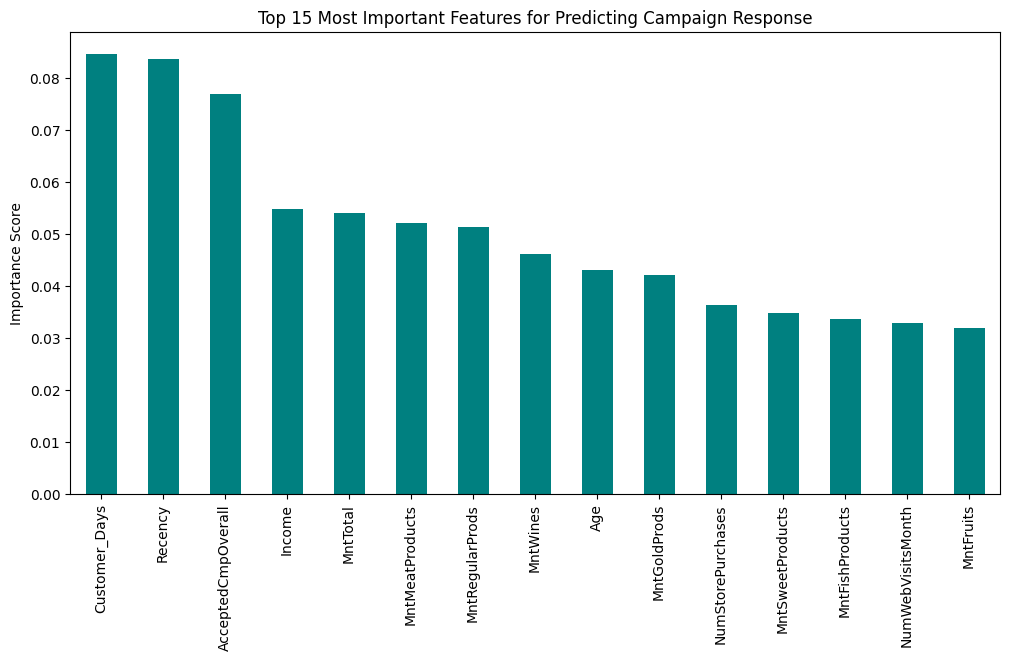

In [7]:

# Define the target variable and features
target = 'Response'

# Drop the target, non-predictive columns, and our newly created segment column
X = df.drop(columns=[target, 'Z_CostContact', 'Z_Revenue', 'Customer_Segment'])
y = df[target]

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Campaign Response')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature Importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
feature_importances.head(15).plot(kind='bar', color='teal')
plt.title('Top 15 Most Important Features for Predicting Campaign Response')
plt.ylabel('Importance Score')
plt.show()